In [2]:
# ==============================
# 1. INSTALL & IMPORTS
# ==============================
!pip install -q opendatasets

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight



In [3]:
# ==============================
# 2. REPRODUCIBILITY
# ==============================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))



TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# ==============================
# 3. DOWNLOAD DATASET
# ==============================
import opendatasets as od
od.download("https://www.kaggle.com/datasets/ebisagetachew/dragamen")

dataset_dir = "dragamen"
train_dir = os.path.join(dataset_dir, "train")
test_dir  = os.path.join(dataset_dir, "test")

print("Train path:", train_dir)
print("Test path:", test_dir)




Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: amen
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/ebisagetachew/dragamen


100%|██████████| 565M/565M [00:07<00:00, 79.8MB/s]



Train path: dragamen/train
Test path: dragamen/test


In [5]:
# ==============================
# 4. PARAMETERS
# ==============================
IMAGE_SIZE = (96, 96)
BATCH_SIZE = 32
EPOCHS = 50
NUM_CLASSES = 7
COLOR_MODE = "rgb"


In [6]:
# ==============================
# 5. DATA GENERATORS
# ==============================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    zoom_range=0.4,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',   # IMPORTANT
    color_mode=COLOR_MODE,
    subset='training',
    seed=SEED
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode=COLOR_MODE,
    subset='validation',
    seed=SEED
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode=COLOR_MODE,
    shuffle=False
)

class_names = list(train_gen.class_indices.keys())
print("Classes:", class_names)




Found 35840 images belonging to 7 classes.
Found 8960 images belonging to 7 classes.
Found 11200 images belonging to 7 classes.
Classes: ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [7]:
# ==============================
# 6. CLASS WEIGHTS
# ==============================
y_train = train_gen.classes
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)


Class Weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0)}


In [8]:
# ==============================
# 7. MODEL (MobileNetV2)
# ==============================
base_model = MobileNetV2(
    input_shape=(96,96,3),
    include_top=False,
    weights='imagenet'
)

# Freeze most layers
for layer in base_model.layers[:100]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

# Label smoothing FIXED
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss=loss_fn,
    metrics=['accuracy']
)

model.summary()



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,588,743 (9.88 MB)

 Trainable params: 2,191,687 (8.36 MB)

 Non-trainable params: 397,056 (1.51 MB)

In [9]:
# ==============================
# 8. CALLBACKS
# ==============================
os.makedirs("models", exist_ok=True)
model_path = "models/best_emotion_model.keras"

callbacks = [
    ModelCheckpoint(model_path, monitor='val_accuracy', save_best_only=True, verbose=1),

    ReduceLROnPlateau(
        monitor='val_loss',
        patience=2,
        factor=0.3,
        min_lr=1e-6,
        verbose=1
    ),

    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]





In [10]:
# ==============================
# 9. TRAIN (PHASE 1)
# ==============================
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights
)



Epoch 1/50
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.2715 - loss: 2.3904
Epoch 1: val_accuracy improved from None to 0.36004, saving model to models/best_emotion_model.keras

Epoch 1: finished saving model to models/best_emotion_model.keras
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 190s 140ms/step - accuracy: 0.3198 - loss: 2.0933 - val_accuracy: 0.3600 - val_loss: 1.8015 - learning_rate: 3.0000e-04
Epoch 2/50
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.4104 - loss: 1.7026
Epoch 2: val_accuracy improved from 0.36004 to 0.46183, saving model to models/best_emotion_model.keras

Epoch 2: finished saving model to models/best_emotion_model.keras
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 150s 134ms/step - accuracy: 0.4340 - loss: 1.6450 - val_accuracy: 0.4618 - val_loss: 1.5373 - learning_rate: 3.0000e-04
Epoch 3/50
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.4730 - loss: 1.5402
Epoch 3: val_accuracy did not improve from 0.46183
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 152s 13

In [11]:
# ==============================
# 10. FINE-TUNING (PHASE 2)
# ==============================
for layer in base_model.layers[-50:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=loss_fn,
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 187s 147ms/step - accuracy: 0.6821 - loss: 1.1106 - val_accuracy: 0.6115 - val_loss: 1.2401
Epoch 2/10
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 172s 153ms/step - accuracy: 0.6802 - loss: 1.1103 - val_accuracy: 0.6117 - val_loss: 1.2439
Epoch 3/10
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 160s 143ms/step - accuracy: 0.6792 - loss: 1.1127 - val_accuracy: 0.6126 - val_loss: 1.2445
Epoch 4/10
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 157s 140ms/step - accuracy: 0.6864 - loss: 1.1052 - val_accuracy: 0.6210 - val_loss: 1.2274
Epoch 5/10
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 156s 139ms/step - accuracy: 0.6796 - loss: 1.1079 - val_accuracy: 0.6179 - val_loss: 1.2280
Epoch 6/10
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 161s 143ms/step - accuracy: 0.6873 - loss: 1.1025 - val_accuracy: 0.6228 - val_loss: 1.2314
Epoch 7/10
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 162s 144ms/step - accuracy: 0.6816 - loss: 1.1030 - val_accuracy: 0.6163 - val_loss: 1.2313
Epoch 8/10
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 172s 154ms/step - ac

In [14]:
# ==============================
# 11. EVALUATION
# ==============================
model = keras.models.load_model(model_path)

# Evaluate
loss, acc = model.evaluate(test_gen, verbose=1)

print(f"\nTest Accuracy: {acc*100:.2f}%")

# Predictions
y_pred_prob = model.predict(test_gen, verbose=1)

y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_gen.classes

# Metrics
f1 = f1_score(y_true, y_pred, average='weighted')
print(f"F1-score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

350/350 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.6438 - loss: 1.1941

Test Accuracy: 64.38%
350/350 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step
F1-score: 0.6438

Classification Report:
              precision    recall  f1-score   support

       anger       0.60      0.56      0.58      1600
     disgust       0.87      0.74      0.80      1600
        fear       0.64      0.37      0.47      1600
       happy       0.77      0.81      0.79      1600
     neutral       0.53      0.66      0.59      1600
         sad       0.45      0.61      0.52      1600
    surprise       0.77      0.75      0.76      1600

    accuracy                           0.64     11200
   macro avg       0.66      0.64      0.64     11200
weighted avg       0.66      0.64      0.64     11200



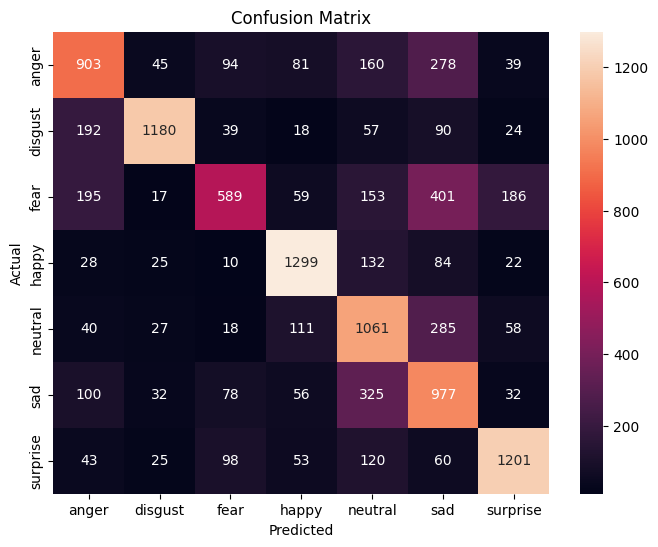

In [15]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()